In [1]:
#importing packages 
import h5py 
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits 

In [2]:
from astropy.coordinates import SkyCoord
import astropy.units as u
#Loading and reading the data 
loadpath = "/Users/alejandrarodriguez/Desktop/Globular_Research/" #use your own path 
filename = "astraAllStarASPCAP-0.8.0.fits" #file name of your data, this code uses .fits
#Please note that the data is not currently included. 
tb = fits.open(loadpath+filename)
data = tb[2].data
col = tb[1].columns

In [3]:
#reading data from APOGEE
ra_ap = data["ra"]
dec_ap = data["dec"]
pmra_ap = data["pmra"]
pmdec_ap = data["pmde"]
gmag_ap = data["g_mag"]
bpmag_ap = data["bp_mag"]
rpmag_ap = data["rp_mag"]
vrad_ap = data["v_rad"]
apid_ap = data["sdss4_apogee_id"]
feh_ap = data["fe_h"]
br = bpmag_ap-rpmag_ap
ebv = data["ebv"]
g = data["g_mag"]
bp = data["bp_mag"]
rp = data["rp_mag"]

##extinction coefficients
a_g = 0.85926*3.1*ebv
a_bp = 1.06794*3.1*ebv
a_rp = 0.651991*3.1*ebv

g0 = g-a_g
bp0 = bp-a_bp
rp0 = rp-a_rp
br0=bp0 - rp0

Text(0.5, 1.0, 'Color-Magnitude Diagram: Pal 5')

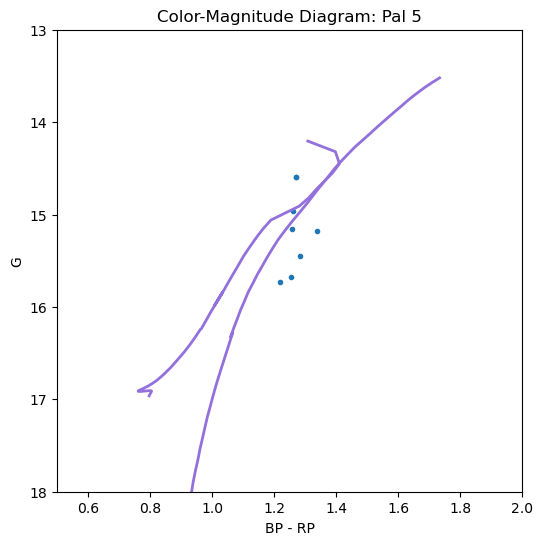

In [4]:
#Pal 5 Globular Cluster 

#mask for ra and dec 
ra_min, ra_max = 225, 233
dec_min, dec_max = -2.5, 2.5

#mask for pmra and pmdec 
pmra_min, pmra_max = -3.0, -2.4
pmdec_min, pmdec_max = -3.0 , -2.2  

#mask for RV 
rv_min, rv_max, = -59, -56

#mask for metallicity 
feh_min, feh_max = -1.325, -1.125


# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_10.9Gyr_mn1.41_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 16.6

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_xlim(0.5,2.0)
ax.set_ylim(18,13)
ax.set_xlabel('BP - RP')
ax.set_ylabel('G')
ax.set_title('Color-Magnitude Diagram: Pal 5')
#ax.legend()

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 362')

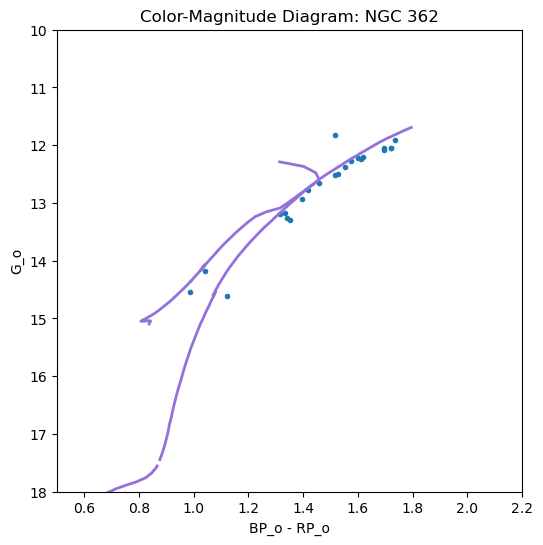

In [5]:
#NGC 362 
#mask for ra and dec 
ra_min, ra_max = 0, 360
dec_min, dec_max = -75, -61

#mask for pmra and pmdec 
pmra_min, pmra_max = 4, 8
pmdec_min, pmdec_max = -6, 0 

#mask for RV 
rv_min, rv_max = 218, 228

#mask for metallicity 
feh_min, feh_max = -1.25, -1.1

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_10.87Gyr_mn1.26_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 14.73

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(18, 10)
ax.set_xlim(0.5, 2.2)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 362')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 6229')

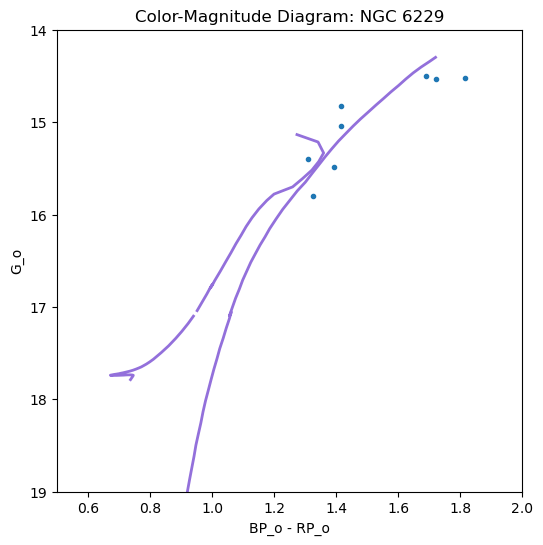

In [6]:
#NGC_6229  

#mask for ra and dec 
ra_min, ra_max = 250, 254
dec_min, dec_max = 44, 49

#mask for pmra and pmdec 
pmra_min, pmra_max = -1.6, -0.8
pmdec_min, pmdec_max = -0.8, -0.2 

#mask for RV 
rv_min, rv_max = -150, -130

#mask for metallicity 
feh_min, feh_max = -1.36, -1.15

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_12Gyr_mn1.47_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 17.39

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(19, 14)
ax.set_xlim(0.5, 2.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 6229')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 6218')

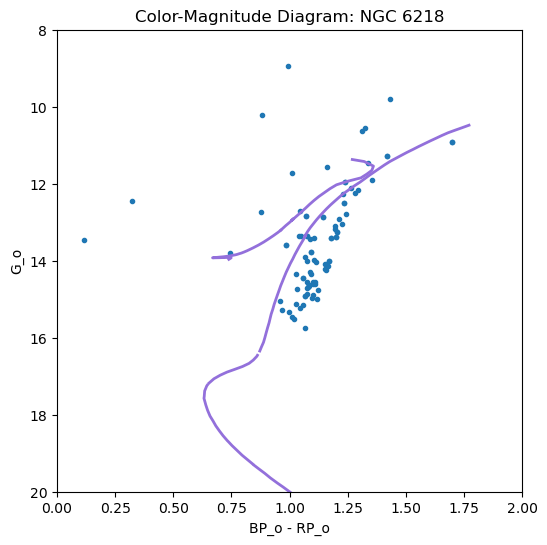

In [7]:
#NGC_6218  

#mask for ra and dec 
ra_min, ra_max = 241, 257
dec_min, dec_max = -6, 0

#mask for pmra and pmdec 
pmra_min, pmra_max = -3, 1
pmdec_min, pmdec_max = -8, -4 

#mask for RV 
rv_min, rv_max, = -50, -35

#mask for metallicity 
feh_min, feh_max = -1.4, -1.2

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask &fehmask

# Load isochrone
gname = 'iso_12.97Gyr_mn1.37_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 13.54

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(20, 8)
ax.set_xlim(0,2.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 6218')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 1904')

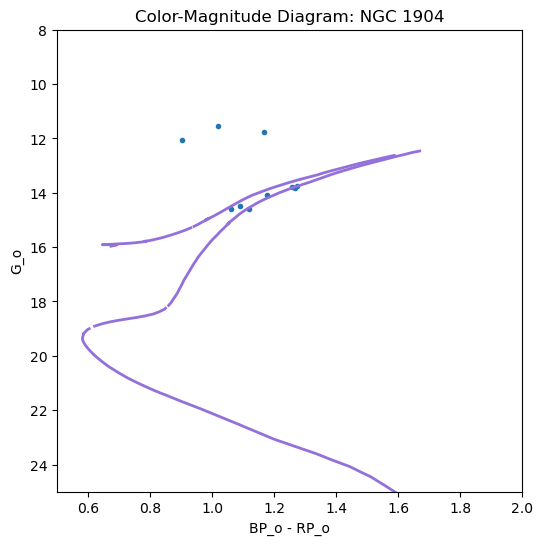

In [8]:
#NGC_1904  

#mask for ra and dec 
ra_min, ra_max = 72, 88
dec_min, dec_max = -33, -17

#mask for pmra and pmdec 
pmra_min, pmra_max = 2, 3
pmdec_min, pmdec_max = -2.6, -1 

#mask for RV 
rv_min, rv_max, = 200, 210

#mask for metallicity 
feh_min, feh_max = -1.7, -1.5

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_11.14Gyr_mn1.60_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.58

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(25, 8)
ax.set_xlim(0.5,2.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 1904')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 6752')

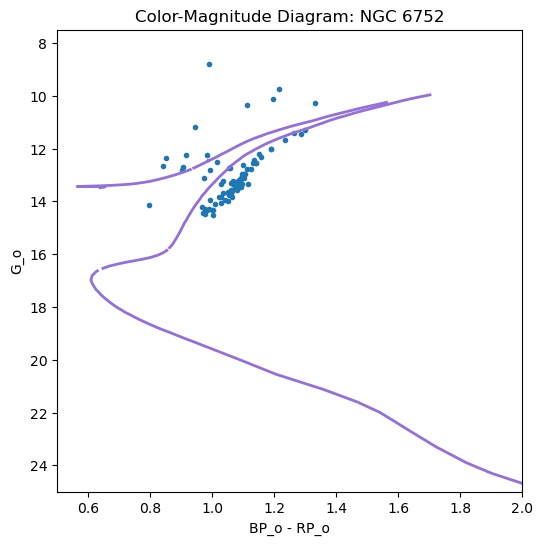

In [9]:
#NGC 6752 
#mask for ra and dec 
ra_min, ra_max = 282, 295
dec_min, dec_max = -75, -50

#mask for pmra and pmdec 
pmra_min, pmra_max = -5, -1
pmdec_min, pmdec_max = -5.5 , -2.5 

#mask for RV 
rv_min, rv_max, = -30, -20

#mask for metallicity 
feh_min, feh_max = -1.56, -1.4

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_12.5Gyr_mn1.54_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 13.07

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)


ax.invert_yaxis()
ax.set_ylim(25, 7.5)
ax.set_xlim(0.5,2)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 6752')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 5904')

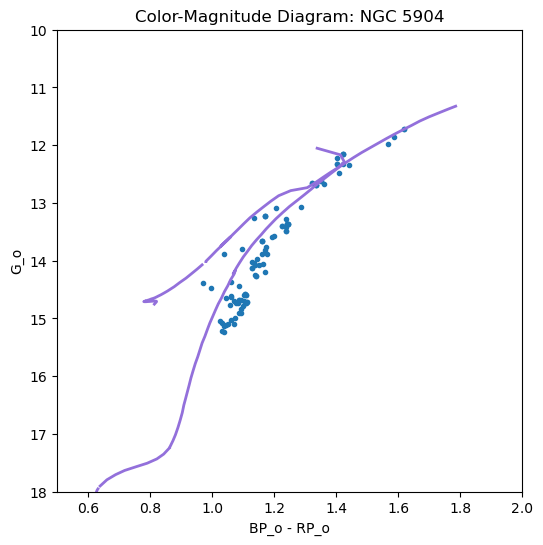

In [10]:
#NGC 5904 
#mask for ra and dec 
ra_min, ra_max = 220, 236
dec_min, dec_max = -2, 8

#mask for pmra and pmdec 
pmra_min, pmra_max = 2.5, 5.5
pmdec_min, pmdec_max = -11.5 , -8.5 

#mask for RV 
rv_min, rv_max, = 50, 56

#mask for metallicity 
feh_min, feh_max = -1.3, -1.1

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask


# Load isochrone
gname = 'iso_11.5Gyr_mn1.3_parsec2.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 14.37

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)


ax.invert_yaxis()
ax.set_ylim(18, 10)
ax.set_xlim(0.5,2.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 5904')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 7089')

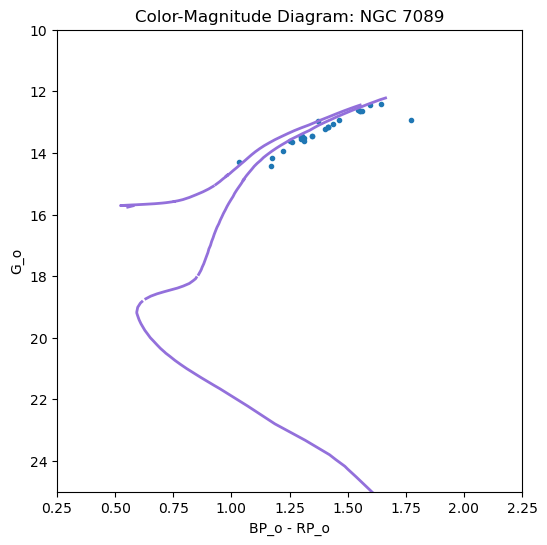

In [11]:
#NGC 7089 
#mask for ra and dec 
ra_min, ra_max = 321.5, 335
dec_min, dec_max = -6, 8

#mask for pmra and pmdec 
pmra_min, pmra_max = 1, 6
pmdec_min, pmdec_max = -4 , -0.5 

#mask for RV 
rv_min, rv_max, = -10, 10

#mask for metallicity 
feh_min, feh_max = -1.50, -1.0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)


combined_mask = pmmask & skymask & rvmask & fehmask


# Load isochrone
gname = 'iso_12.01Gyr_mn1.65_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.34


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(25, 10)
ax.set_xlim(0.25, 2.25)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 7089')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 6205')

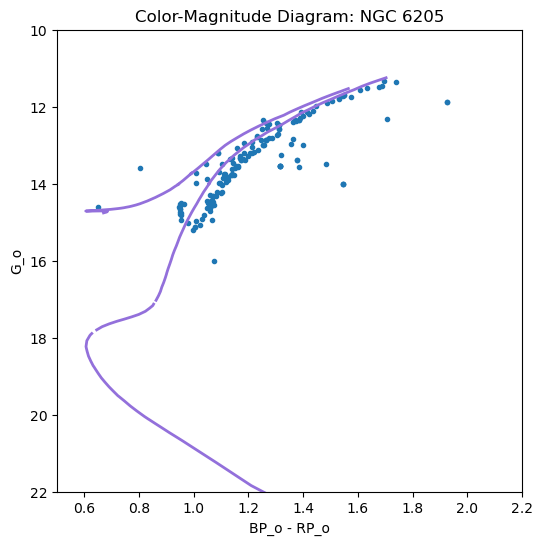

In [12]:
#NGC 6205 
#mask for ra and dec 
ra_min, ra_max = 235, 265
dec_min, dec_max = 27, 42

#mask for pmra and pmdec 
pmra_min, pmra_max = -5.5, -1.5
pmdec_min, pmdec_max = -7 , 0 

#mask for RV 
rv_min, rv_max, = -260, -200

#mask for metallicity 
feh_min, feh_max = -1.75, -1.0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)


combined_mask = pmmask & skymask & rvmask & fehmask


# Load isochrone
gname = 'iso_12.22Gyr_mn1.53_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 14.35

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(22, 10)
ax.set_xlim(0.5, 2.2)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 6205')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 4590')

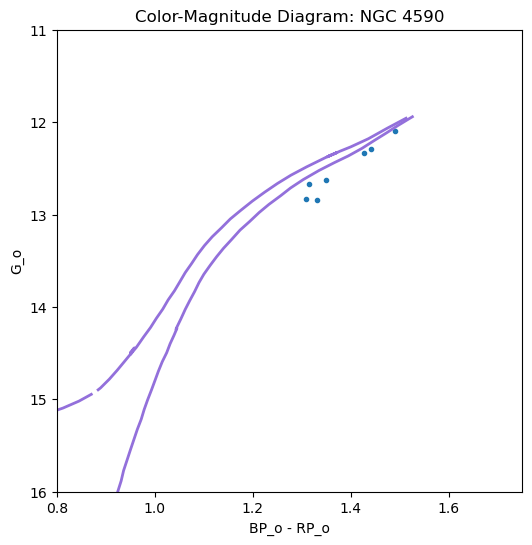

In [13]:
#NGC 4590 
#mask for ra and dec 
ra_min, ra_max = 187, 193
dec_min, dec_max = -37.5, -17

#mask for pmra and pmdec 
pmra_min, pmra_max = -4.0, -1.5
pmdec_min, pmdec_max = 0.75, 2.75 

#mask for RV 
rv_min, rv_max, = -96, -88

#mask for metallicity 
feh_min, feh_max = -2.3, -2.0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask


# Load isochrone
gname = 'iso_12.17Gyr_mn2.23_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.09

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(16, 11)
ax.set_xlim(0.8,1.75)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 4590')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 6341')

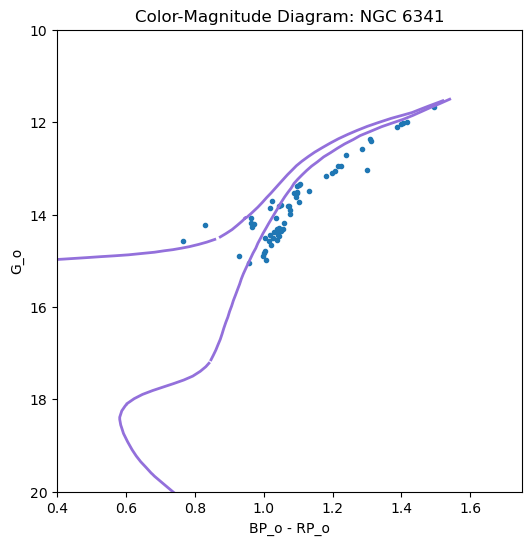

In [14]:
#NGC 6341 
#mask for ra and dec 
ra_min, ra_max = 245, 270
dec_min, dec_max = 35, 48

#mask for pmra and pmdec 
pmra_min, pmra_max = -6, -4
pmdec_min, pmdec_max = -4, 2 

#mask for RV 
rv_min, rv_max, = -125, -115

#mask for metallicity 
feh_min, feh_max = -2.5, -2.0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask


# Load isochrone
gname = 'iso_13.06Gyr_mn2.31_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 14.65

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(20, 10)
ax.set_xlim(0.4,1.75)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 6341')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 5272')

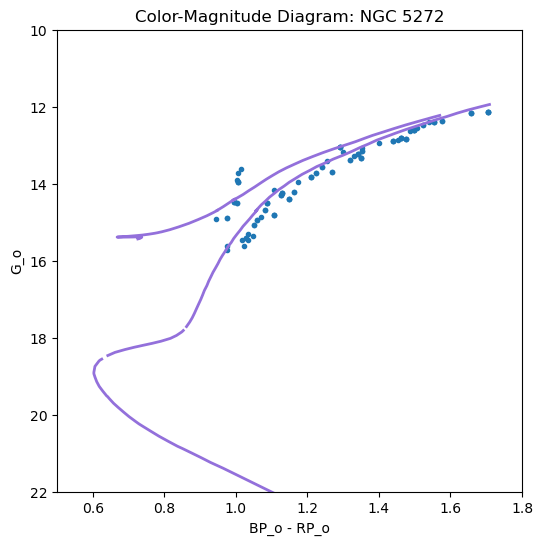

In [36]:
#NGC 5272 
#mask for ra and dec 
ra_min, ra_max = 185, 230
dec_min, dec_max = 16, 32

#mask for pmra and pmdec 
pmra_min, pmra_max = -2.5, 2.0
pmdec_min, pmdec_max = -4.5, -0.5 

#mask for RV 
rv_min, rv_max = -150, -143

#mask for metallicity 
feh_min, feh_max = -1.4, -1.3

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask


# Load isochrone
gname = 'iso_11.88Gyr_mn1.50_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.04


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(22, 10)
ax.set_xlim(0.5,1.8)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 5272')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 7099')

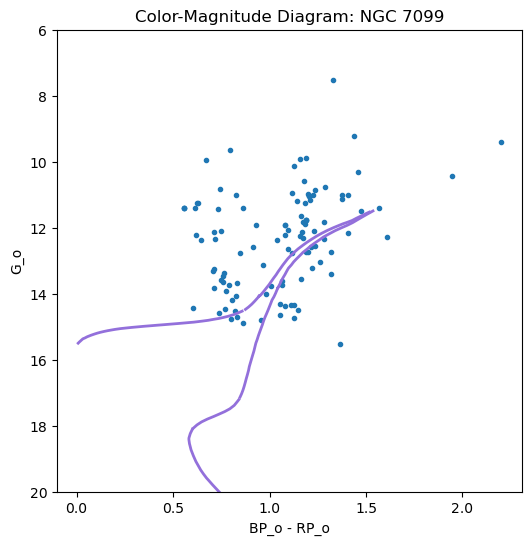

In [16]:
#NGC 7099 
#mask for ra and dec 
ra_min, ra_max = 314, 333
dec_min, dec_max = -29, -14

#mask for pmra and pmdec 
pmra_min, pmra_max = -5, 3
pmdec_min, pmdec_max = -10 , -4 

#mask for RV 
rv_min, rv_max, = -25, 25

#mask for metallicity 
feh_min, feh_max = -0.5, 0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask


# Load isochrone
gname = 'iso_13.06Gyr_mn2.27_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 14.64

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(20, 6)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 7099')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 1851')

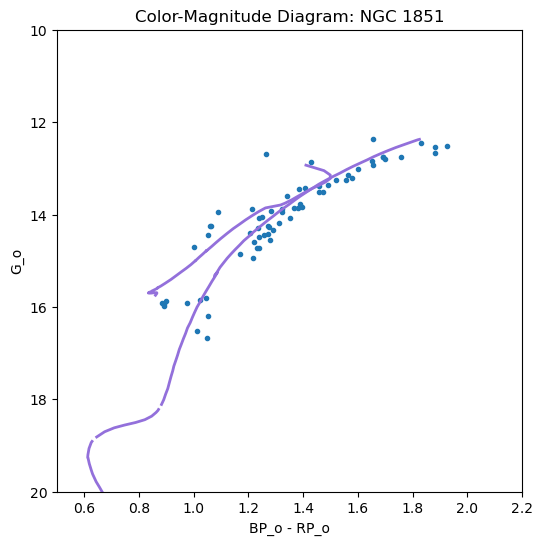

In [17]:
#NGC 1851 
#mask for ra and dec 
ra_min, ra_max = 64, 92
dec_min, dec_max = -52, -25

#mask for pmra and pmdec 
pmra_min, pmra_max = 0.5, 3.5
pmdec_min, pmdec_max = -3 , 3 

#mask for RV 
rv_min, rv_max, = 310, 330

#mask for metallicity 
feh_min, feh_max = -1.4, -0.8

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask &fehmask


# Load isochrone
gname = 'iso_10.49Gyr_mn1.18_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.39

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(20, 10)
ax.set_xlim(0.5,2.2)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 1851')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 6934')

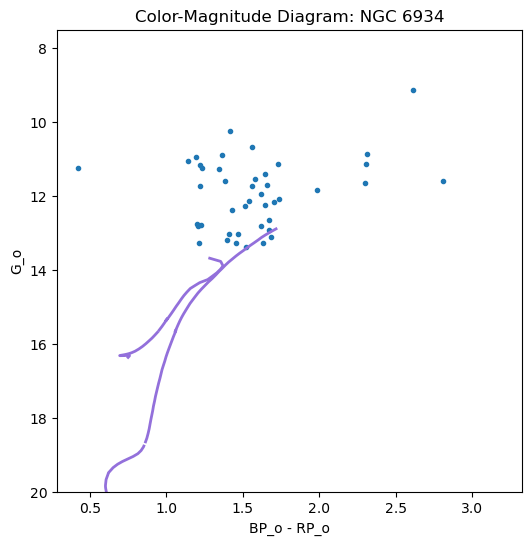

In [18]:
#NGC 6934 
#mask for ra and dec 
ra_min, ra_max = 305, 315
dec_min, dec_max = 4, 14

#mask for pmra and pmdec 
pmra_min, pmra_max = -3.2, -1.6
pmdec_min, pmdec_max = -5.50 , -3.25 

#mask for RV 
rv_min, rv_max, = -30, 30

#mask for metallicity 
feh_min, feh_max = -0.7, 0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask &fehmask 


# Load isochrone
gname = 'iso_11.63Gyr_mn1.47_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.98


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(20, 7.5)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 6934')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 5897')

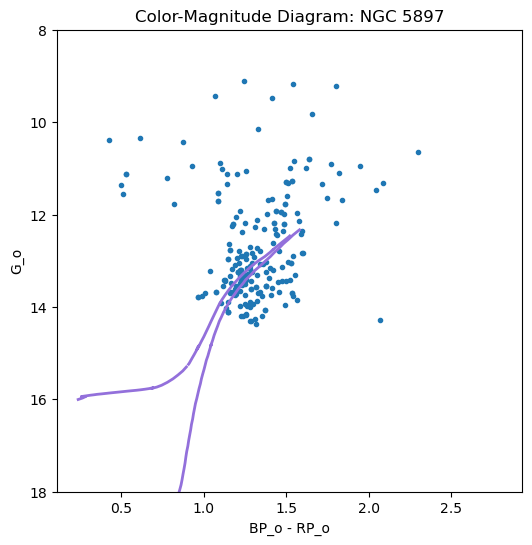

In [19]:
#NGC 5897 
#mask for ra and dec 
ra_min, ra_max = 215, 245
dec_min, dec_max = -27, -18

#mask for pmra and pmdec 
pmra_min, pmra_max = -8, -3
pmdec_min, pmdec_max = -5 , -2 

#mask for RV 
rv_min, rv_max, = -50, 50

#mask for metallicity 
feh_min, feh_max = -1.0, 0


# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask 


# Load isochrone
gname = 'iso_12.30Gyr_mn1.90_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.49


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(18, 8)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 5897')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 5024')

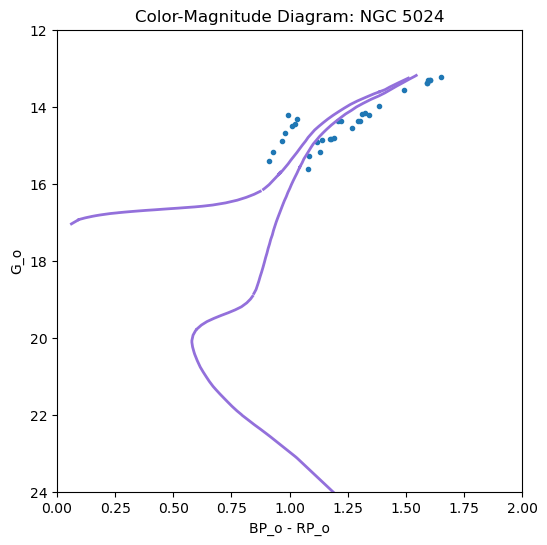

In [20]:
#NGC 5024 
#mask for ra and dec 
ra_min, ra_max = 180, 210
dec_min, dec_max = 8, 24

#mask for pmra and pmdec 
pmra_min, pmra_max = -1.5, 2.0
pmdec_min, pmdec_max = -2.5 , 1.0

#mask for RV 
rv_min, rv_max, = -65, -55

#mask for metallicity 
feh_min, feh_max = -2.2, -1.6

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask


# Load isochrone
gname = 'iso_12.72Gyr_mn2.10_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 16.34

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(24, 12)
ax.set_xlim(0,2.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 5024')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 7078')

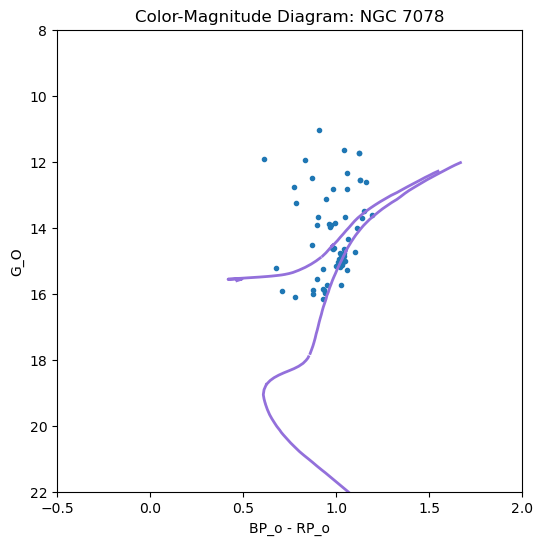

In [21]:
#NGC 7078 
#mask for ra and dec 
ra_min, ra_max = 314, 328
dec_min, dec_max = 4, 24

#mask for pmra and pmdec 
pmra_min, pmra_max = -3, 3
pmdec_min, pmdec_max = -5, -2.5 

#mask for RV 
rv_min, rv_max, = -110, -105

#mask for metallicity 
feh_min, feh_max = -2.5, -1.3

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_12.98Gyr_mn1.65_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.15

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)


ax.invert_yaxis()
ax.set_ylim(22, 8)
ax.set_xlim(-0.5,2)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_O')
ax.set_title('Color-Magnitude Diagram: NGC 7078')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 5466')

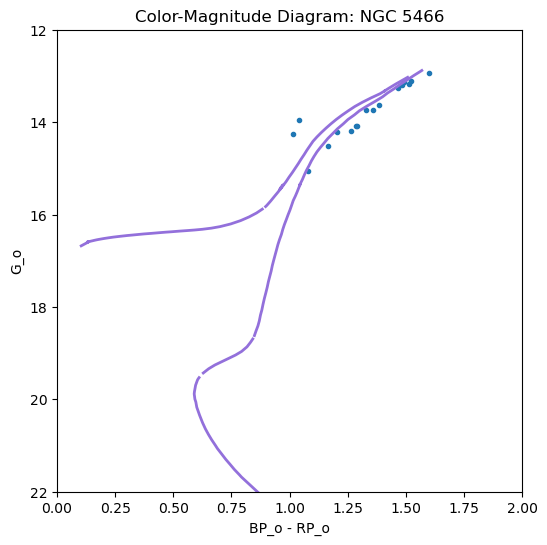

In [22]:
#NGC 5466 
#mask for ra and dec 
ra_min, ra_max = 195, 225
dec_min, dec_max = 28, 34

#mask for pmra and pmdec 
pmra_min, pmra_max = -7, -3.5
pmdec_min, pmdec_max = -1.75, 0.5 

#mask for RV 
rv_min, rv_max, = 100, 115

#mask for metallicity 
feh_min, feh_max = -2.0, -1.6

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)


combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_13.02Gyr_mn1.98_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 16.04


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(22, 12)
ax.set_xlim(0,2.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 5466')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 6981')

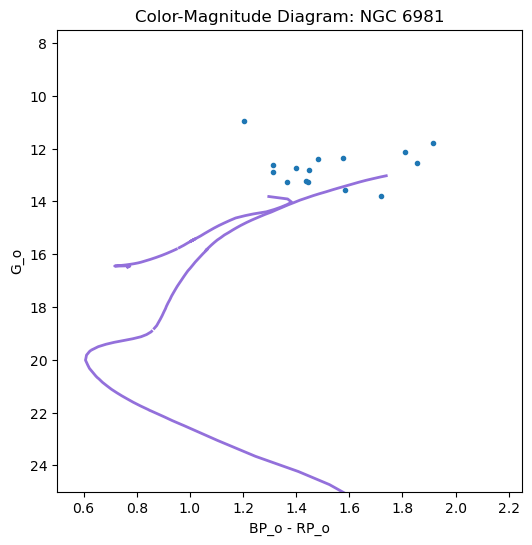

In [23]:
#NGC 6981 
#mask for ra and dec 
ra_min, ra_max = 302.5, 320
dec_min, dec_max = -18, -8

#mask for pmra and pmdec 
pmra_min, pmra_max = -4, 0.5
pmdec_min, pmdec_max = -6, 2 

#mask for RV 
rv_min, rv_max, = -300, -100

#mask for metallicity 
feh_min, feh_max = -1.5, -1.0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)


combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_11.71Gyr_mn1.42_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 16.11


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(25, 7.5)
ax.set_xlim(0.5,2.25)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 6981')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 1261')

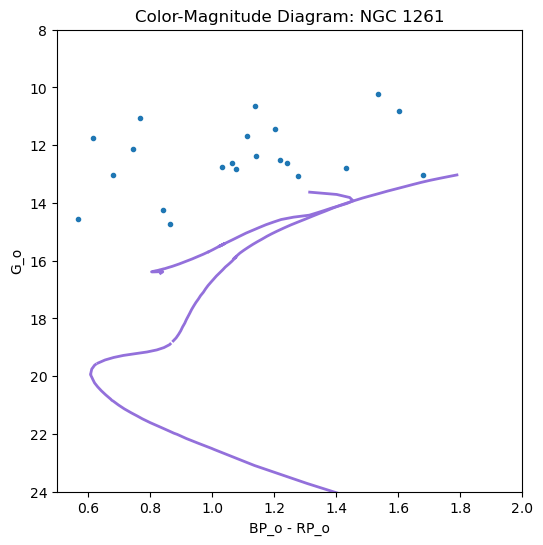

In [24]:
#NGC 1261
#mask for ra and dec 
ra_min, ra_max = 30, 60
dec_min, dec_max = -65, -45

#mask for pmra and pmdec 
pmra_min, pmra_max = 0.75, 2.75
pmdec_min, pmdec_max = -4, -0.5 

#mask for RV 
rv_min, rv_max, = 20, 90

#mask for metallicity 
feh_min, feh_max = -1.0, 0.25

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_10.83Gyr_mn1.27_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 16.07

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(24, 8)
ax.set_xlim(0.5,2.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 1261')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 5824')

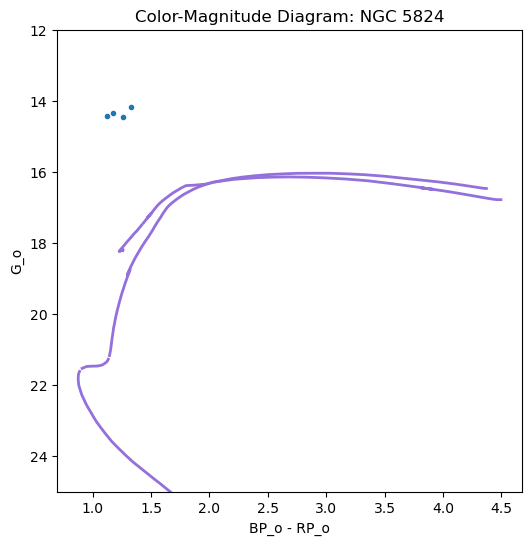

In [25]:
#NGC 5824
#mask for ra and dec 
ra_min, ra_max = 224, 227.5
dec_min, dec_max = -45, -20

#mask for pmra and pmdec 
pmra_min, pmra_max = -3, 0
pmdec_min, pmdec_max = -3.25, -1.25 

#mask for RV 
rv_min, rv_max, = -30, 50

#mask for metallicity 
feh_min, feh_max = -0.5, -0.3

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)


#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask 

# Load isochrone
gname = 'iso_12.80Gyr_mn1.91_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 17.51

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(25, 12)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 5824')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 5053')

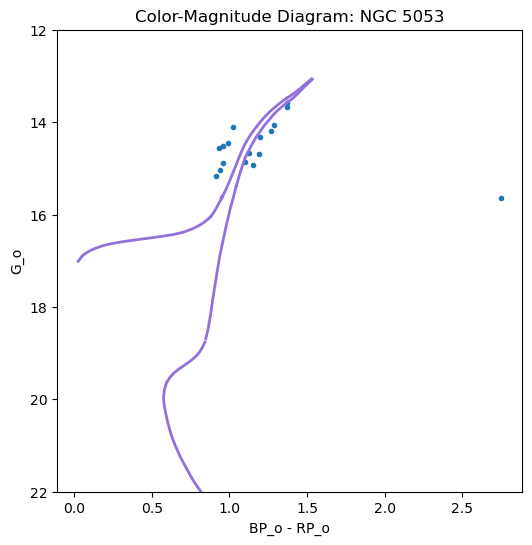

In [26]:
#NGC 5053
#mask for ra and dec 
ra_min, ra_max = 190, 210
dec_min, dec_max = 10, 24

#mask for pmra and pmdec 
pmra_min, pmra_max = -2, 2
pmdec_min, pmdec_max = -2.5, 1.0 

#mask for RV 
rv_min, rv_max, = 35, 50

#mask for metallicity 
feh_min, feh_max = -2.5, -2.0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_12.68Gyr_mn2.27_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 16.22

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(22, 12)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 5053')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 288')

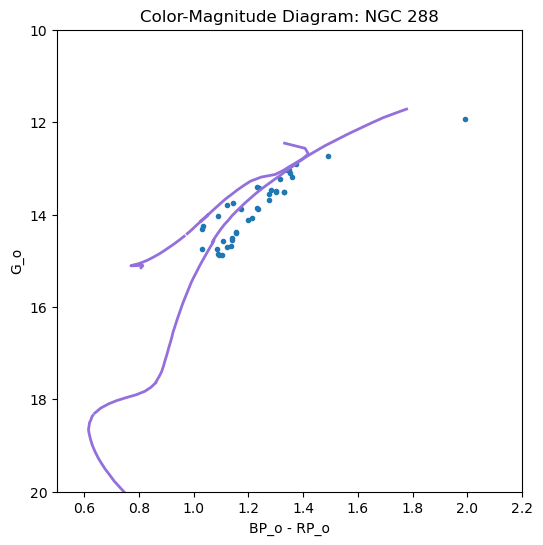

In [27]:
#NGC 288
#mask for ra and dec 
ra_min, ra_max = 2, 18
dec_min, dec_max = -36, -18

#mask for pmra and pmdec 
pmra_min, pmra_max = 1.5, 6
pmdec_min, pmdec_max = -9, -3 

#mask for RV 
rv_min, rv_max, = -50, -38

#mask for metallicity 
feh_min, feh_max = -1.4, -1.0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_11.54Gyr_mn1.32_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 14.77


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(20, 10)
ax.set_xlim(0.5,2.2)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 288')

Text(0.5, 1.0, 'Color-Magnitude Diagram: Pal 1')

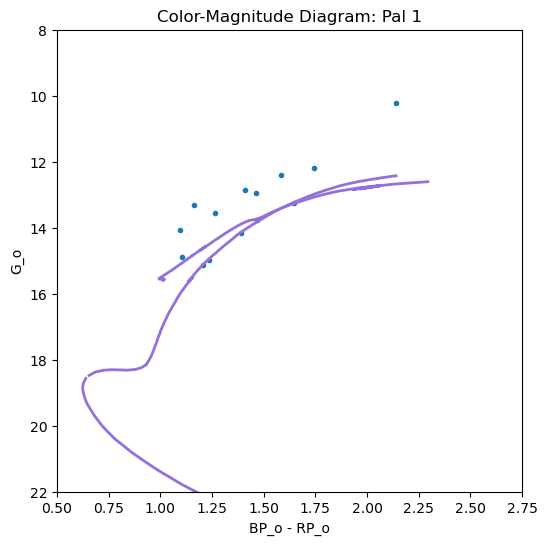

In [28]:
#Pal 1
#mask for ra and dec 
ra_min, ra_max = 30, 75
dec_min, dec_max = 77, 80.5

#mask for pmra and pmdec 
pmra_min, pmra_max = -1, 0.6
pmdec_min, pmdec_max = -2, 1.0 

#mask for RV 
rv_min, rv_max, = -100, -60

#mask for metallicity 
feh_min, feh_max = -0.7, -0.5

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_7.30Gyr_mn0.65_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 15.24

label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(22, 8)
ax.set_xlim(0.5, 2.75)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: Pal 1')

Text(0.5, 1.0, 'Color-Magnitude Diagram: Whiting 1')

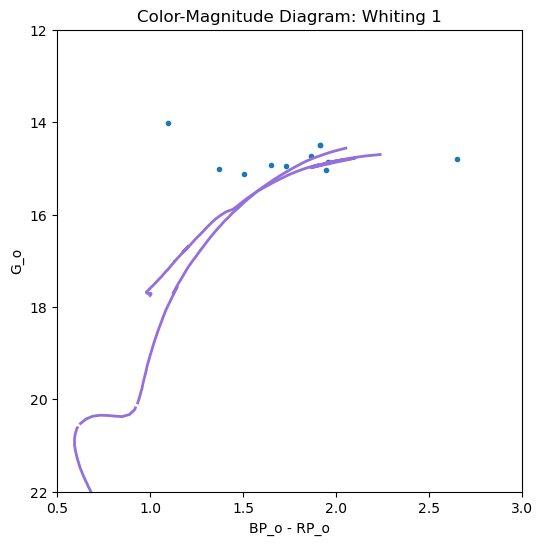

In [29]:
#Whiting 1
#mask for ra and dec 
ra_min, ra_max = 27, 34
dec_min, dec_max = -5.5, -1.0

#mask for pmra and pmdec 
pmra_min, pmra_max = -1.5, 1
pmdec_min, pmdec_max = -2.8, -1.6 

#mask for RV 
rv_min, rv_max, = -150, 0

#mask for metallicity 
feh_min, feh_max = -1.0, -0.25

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)


combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_6.50Gyr_mn0.70_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 17.43



label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(22, 12)
ax.set_xlim(0.5,3.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: Whiting 1')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 4147')

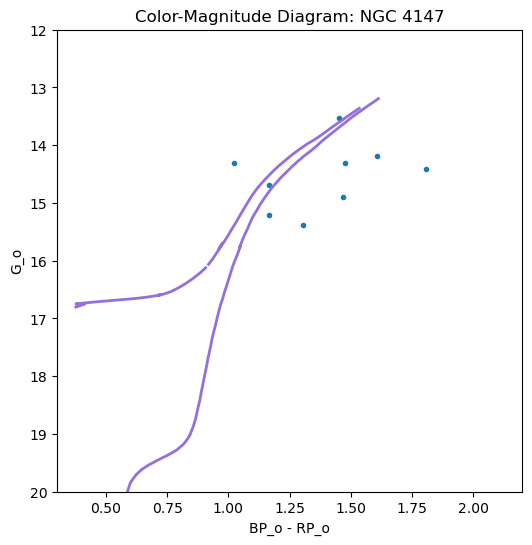

In [30]:
#NGC 4147
#mask for ra and dec 
ra_min, ra_max = 180, 186
dec_min, dec_max = 14, 21

#mask for pmra and pmdec 
pmra_min, pmra_max = -3, -0.5
pmdec_min, pmdec_max = -3.25, -1.25 

#mask for RV 
rv_min, rv_max, = 0, 160

#mask for metallicity 
feh_min, feh_max = -2.5, -1.0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_12.13Gyr_mn1.80_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 16.34


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(20, 12)
ax.set_xlim(0.3,2.2)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 4147')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 5634')

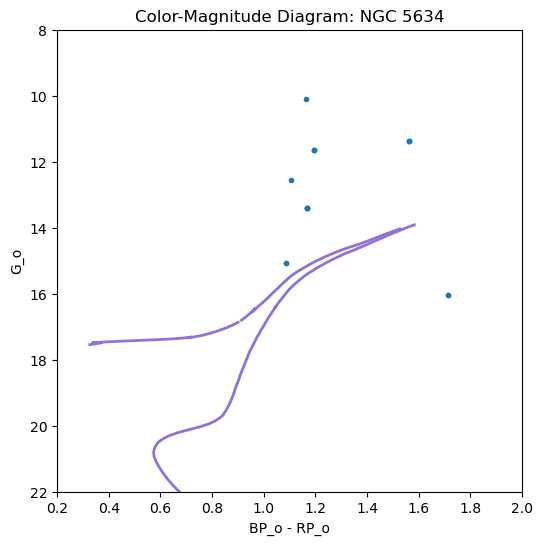

In [31]:
#NGC 5634
#mask for ra and dec 
ra_min, ra_max = 213, 220
dec_min, dec_max = -9, -5

#mask for pmra and pmdec 
pmra_min, pmra_max = -3, -0.75
pmdec_min, pmdec_max = -2.6, 0.8

#mask for RV 
rv_min, rv_max, = -60, -20

#mask for metallicity 
feh_min, feh_max = -2, 0

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_11.84Gyr_mn1.88_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 17.07


label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(22, 8)
ax.set_xlim(0.2,2.0)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 5634')

Text(0.5, 1.0, 'Color-Magnitude Diagram: NGC 2419')

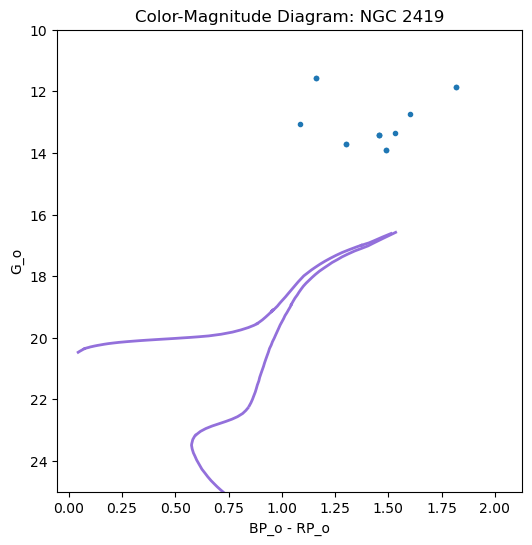

In [32]:
#NO LONGER IN LIST 
#NGC 2419
#mask for ra and dec 
ra_min, ra_max = 110, 118
dec_min, dec_max = 37.5, 40.5

#mask for pmra and pmdec 
pmra_min, pmra_max = -0.8, 0.8
pmdec_min, pmdec_max = -1.0, 0

#mask for RV 
rv_min, rv_max, = -50, 50

#mask for metallicity 
feh_min, feh_max = -0.7, -0.5

# Create mask for stars in the RA/Dec range
skymask = (ra_ap > ra_min) & (ra_ap < ra_max) & \
       (dec_ap > dec_min) & (dec_ap < dec_max)


#mask for the proper motion 
pmmask = (pmra_ap > pmra_min) & (pmra_ap < pmra_max) & \
          (pmdec_ap > pmdec_min) & (pmdec_ap < pmdec_max)


#mask for the rv 
rvmask = (vrad_ap > rv_min) & (vrad_ap < rv_max)

#mask for the metallicity 
fehmask = (feh_ap > feh_min) & (feh_ap < feh_max)

combined_mask = pmmask & skymask & rvmask & fehmask

# Load isochrone
gname = 'iso_12.65Gyr_mn2.15_parsec.txt'
gdata = np.loadtxt(gname)
igg  = gdata[:, 28]
igbp = gdata[:, 29]
igrp = gdata[:, 30]
igbr = igbp - igrp
iapp_gg = igg + 19.73



label = gdata[:,9]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(bp0[combined_mask] - rp0[combined_mask],g0[combined_mask],'o',ms=3)

for lab in [1,2,3,4,5,6,7]:
    m=label==lab
    ax.plot(igbr[m], iapp_gg[m],color='mediumpurple', lw=2)

ax.invert_yaxis()
ax.set_ylim(25, 10)
ax.set_xlabel('BP_o - RP_o')
ax.set_ylabel('G_o')
ax.set_title('Color-Magnitude Diagram: NGC 2419')